# VP negativity lines vs lattice constant

Scan vp negativity ratios over a lattice-constant grid from a=1.5 to a=10.
Includes both the unweighted ratio and a density-weighted ratio.


In [1]:
import numpy as np
import pandas as pd

from dftpy.ions import Ions
from dftpy.field import DirectField
from dftpy.grid import DirectGrid
from dftpy.functional import LocalPseudo, Functional, TotalFunctional
from dftpy.math_utils import ecut2nr
from dftpy.optimization import Optimization
from dftpy.constants import environ


In [2]:
environ["LOGLEVEL"] = 4
# Update this path if needed
path_pp = "/Users/michele/Documents/hackathon/KEDF-scaling/OEPP_lib/OEPP/RECPOT/"


## Helpers


In [3]:
def get_pp_list(atom_type):
    import os
    if not os.path.isdir(path_pp):
        raise FileNotFoundError(f"Pseudopotential directory not found: {path_pp}")
    matches = [f for f in os.listdir(path_pp) if f.startswith(atom_type + "_")]
    if not matches:
        raise FileNotFoundError(f"No pseudopotential found for {atom_type} in {path_pp}")
    file_pp = matches[0]
    return {atom_type: path_pp + file_pp}


def get_ions(atom_type, phase, a=None):
    if a is None:
        raise ValueError("Provide lattice constant a")
    from ase.build import bulk
    atoms = bulk(atom_type, phase, a=a)
    ions = Ions.from_ase(atoms)
    return ions


def optimize_rho(kedf, atom_type, phase, a, rhoi=None, ecut=35, **kedf_options):
    ions = get_ions(atom_type, phase, a)
    nr = ecut2nr(ecut=ecut, lattice=ions.cell)
    grid = DirectGrid(lattice=ions.cell, nr=nr)
    pseudo = LocalPseudo(grid=grid, ions=ions, PP_list=get_pp_list(atom_type))
    rho_ini = DirectField(grid=grid)
    rho_ini[:] = ions.get_ncharges() / ions.cell.volume
    if rhoi is not None:
        rho_ini = rhoi
    ke = Functional(type="KEDF", name=kedf, **kedf_options)
    xc = Functional(type="XC", name="LDA")
    hartree = Functional(type="HARTREE")
    evaluator = TotalFunctional(KE=ke, XC=xc, HARTREE=hartree, PSEUDO=pseudo)
    opt = Optimization(
        EnergyEvaluator=evaluator,
        optimization_options={"econv": 1e-6},
        optimization_method="CG",
    )
    rho = opt.optimize_rho(guess_rho=rho_ini)
    return rho


## VP negativity ratios (unweighted + density-weighted)


In [4]:
def vp_neg_ratio(kedf, rho, **kedf_options):
    KE = Functional(type="KEDF", name=kedf, **kedf_options)
    VW = Functional(type="KEDF", name="vW")

    vs = KE(rho).potential
    vvw = VW(rho).potential
    vp = vs - vvw
    absvp = np.abs(vp)
    return (vp - absvp).integral() / absvp.integral()


def vp_neg_ratio_weighted(kedf, rho, **kedf_options):
    KE = Functional(type="KEDF", name=kedf, **kedf_options)
    VW = Functional(type="KEDF", name="vW")

    vs = KE(rho).potential
    vvw = VW(rho).potential
    vp = vs - vvw
    absvp = np.abs(vp)

    num = ((vp - absvp) * rho).integral()
    den = (absvp * rho).integral()
    return num / den


## Scan a = 5 to 20.0


In [5]:
# Inputs
atoms = ["Al", "Si", "Sn"]
phases = ["fcc", "bcc", "diamond"]

KEDF_SPECS = [
    ("WT", {}, "WT"),
    ("WT", {"rho0": 0.3}, r"WT $\bar n = 0.3$"),
    ("WTE", {}, "WTE"),
]

a_values = np.linspace(5, 20.0, 16)

rows = []

for atom in atoms:
    for phase in phases:
        for kedf, kedf_options, kedf_label in KEDF_SPECS:
            for a in a_values:
                print(f"{atom} {phase} {kedf} a={a:.3f}")
                rho = optimize_rho(kedf, atom, phase, a, rhoi=None, **kedf_options)
                vp_ratio = vp_neg_ratio(kedf, rho, **kedf_options)
                vp_ratio_weighted = vp_neg_ratio_weighted(kedf, rho, **kedf_options)
                KE = Functional(type="KEDF", name=kedf, **kedf_options)
                VW = Functional(type="KEDF", name="vW")
                pauli_energy = KE(rho).energy - VW(rho).energy

                rows.append({
                    "Atom": atom,
                    "Phase": phase,
                    "KEDF": kedf_label,
                    "a": a,
                    "vp_ratio": vp_ratio,
                    "vp_ratio_weighted": vp_ratio_weighted,
                    "pauli_energy": pauli_energy,
                })

results_df = pd.DataFrame(rows)
results_df


Al fcc WT a=5.000
Al fcc WT a=6.000
Al fcc WT a=7.000
Al fcc WT a=8.000
Al fcc WT a=9.000
Al fcc WT a=10.000
Al fcc WT a=11.000
Al fcc WT a=12.000
Al fcc WT a=13.000
Al fcc WT a=14.000
Al fcc WT a=15.000
Al fcc WT a=16.000
Al fcc WT a=17.000
Al fcc WT a=18.000
Al fcc WT a=19.000
Al fcc WT a=20.000
Al fcc WT a=5.000
Al fcc WT a=6.000
Al fcc WT a=7.000
Al fcc WT a=8.000
Al fcc WT a=9.000
Al fcc WT a=10.000
Al fcc WT a=11.000
Al fcc WT a=12.000
Al fcc WT a=13.000
Al fcc WT a=14.000
Al fcc WT a=15.000
Al fcc WT a=16.000
Al fcc WT a=17.000
Al fcc WT a=18.000
Al fcc WT a=19.000
Al fcc WT a=20.000
Al fcc WTE a=5.000
Al fcc WTE a=6.000
Al fcc WTE a=7.000
Al fcc WTE a=8.000
Al fcc WTE a=9.000
Al fcc WTE a=10.000
Al fcc WTE a=11.000
Al fcc WTE a=12.000
Al fcc WTE a=13.000
Al fcc WTE a=14.000
Al fcc WTE a=15.000
Al fcc WTE a=16.000
Al fcc WTE a=17.000
Al fcc WTE a=18.000
Al fcc WTE a=19.000
Al fcc WTE a=20.000
Al bcc WT a=5.000
Al bcc WT a=6.000
Al bcc WT a=7.000
Al bcc WT a=8.000
Al bcc WT a=9.0

,Atom,Phase,KEDF,a,vp_ratio,vp_ratio_weighted,pauli_energy
0,Al,fcc,WT,5.0,0.000000,0.000000,0.480054
1,Al,fcc,WT,6.0,0.000000,0.000000,0.261420
2,Al,fcc,WT,7.0,-0.017892,-0.266390,0.096110
3,Al,fcc,WT,8.0,-0.054987,-1.085068,-0.010329
4,Al,fcc,WT,9.0,-0.072443,-1.552822,-0.073628
...,...,...,...,...,...,...,...
427,Sn,diamond,WTE,16.0,-0.260371,-0.000021,0.504941
428,Sn,diamond,WTE,17.0,-0.295035,-0.000011,0.491059
429,Sn,diamond,WTE,18.0,-0.333763,-0.000005,0.480434
430,Sn,diamond,WTE,19.0,-0.361917,-0.000003,0.472139


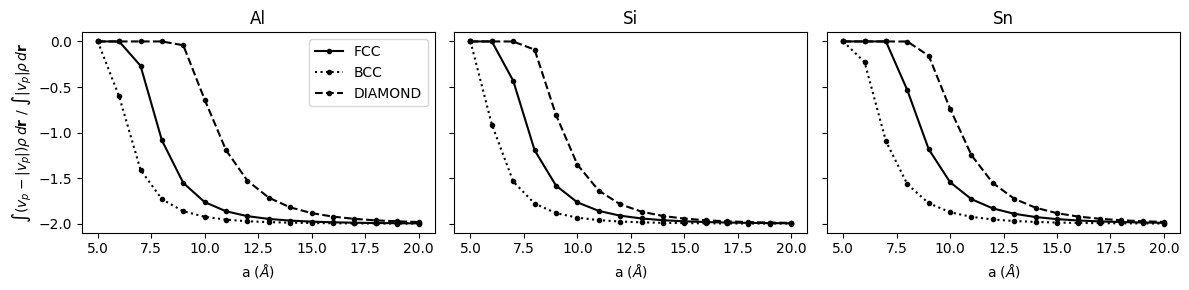

In [19]:
import matplotlib.pyplot as plt

kedf_label = "WT"
#kedf_label = "WTE"
atoms = ["Al", "Si", "Sn"]
phases = ["fcc", "bcc", "diamond"]

fig, axes = plt.subplots(1, len(atoms), figsize=(12, 3), sharey=True)

for ax, atom in zip(axes, atoms):
    for phase in phases:
        mask = (
            (results_df["Atom"] == atom)
            & (results_df["Phase"] == phase)
            & (results_df["KEDF"] == kedf_label)
        )
        data = results_df.loc[mask].sort_values("a")
        
        if phase == 'fcc': 
            color = 'k'
            ls = '-'
        if phase == 'bcc': 
            color = 'k'
            ls = ':'
        if phase == 'diamond': 
            color = 'k'
            ls = '--'
        ax.plot(
            data["a"],
            data["vp_ratio_weighted"],
                        label=phase.upper(),
                        color = color,
                        marker = "o",
                        markersize=3,
                        ls = ls,
        )
    ax.set_title(atom)
    ax.set_xlabel(r"a ($\AA$)")

axes[0].set_ylabel(r"$\int (v_p-|v_p|) \rho \, d\mathbf{r} ~ / ~ \int |v_p| \rho \, d\mathbf{r}$")
axes[0].legend()
plt.tight_layout()
plt.savefig("vp_positivity_WT.pdf")


In [7]:
import os

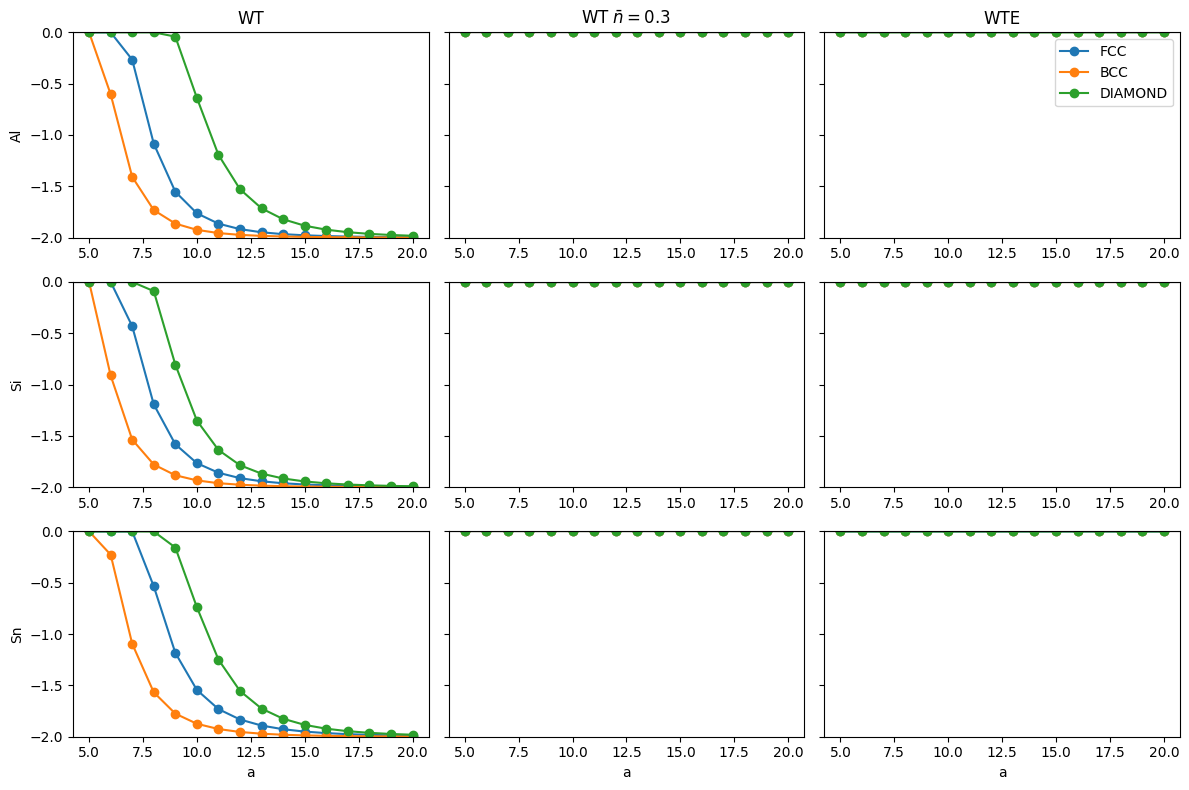

In [8]:
import matplotlib.pyplot as plt

atoms = ["Al", "Si", "Sn"]
phases = ["fcc", "bcc", "diamond"]
kedf_labels = ["WT", r"WT $\bar n = 0.3$", "WTE"]

fig, axes = plt.subplots(len(atoms), len(kedf_labels), figsize=(12, 8), sharey=True)

for i, atom in enumerate(atoms):
    for j, kedf_label in enumerate(kedf_labels):
        ax = axes[i, j]
        for phase in phases:
            mask = (
                (results_df["Atom"] == atom)
                & (results_df["Phase"] == phase)
                & (results_df["KEDF"] == kedf_label)
            )
            data = results_df.loc[mask].sort_values("a")
            ax.plot(
                data["a"],
                data["vp_ratio_weighted"],
                marker="o",
                label=phase.upper(),
            )
        ax.axhline(0.0, color="k", linewidth=0.8)
        ax.set_ylim([-2, 0])

        if i == 0:
            ax.set_title(kedf_label)
        if j == 0:
            ax.set_ylabel(atom)
        if i == len(atoms) - 1:
            ax.set_xlabel("a")

axes[0, -1].legend()
plt.tight_layout()



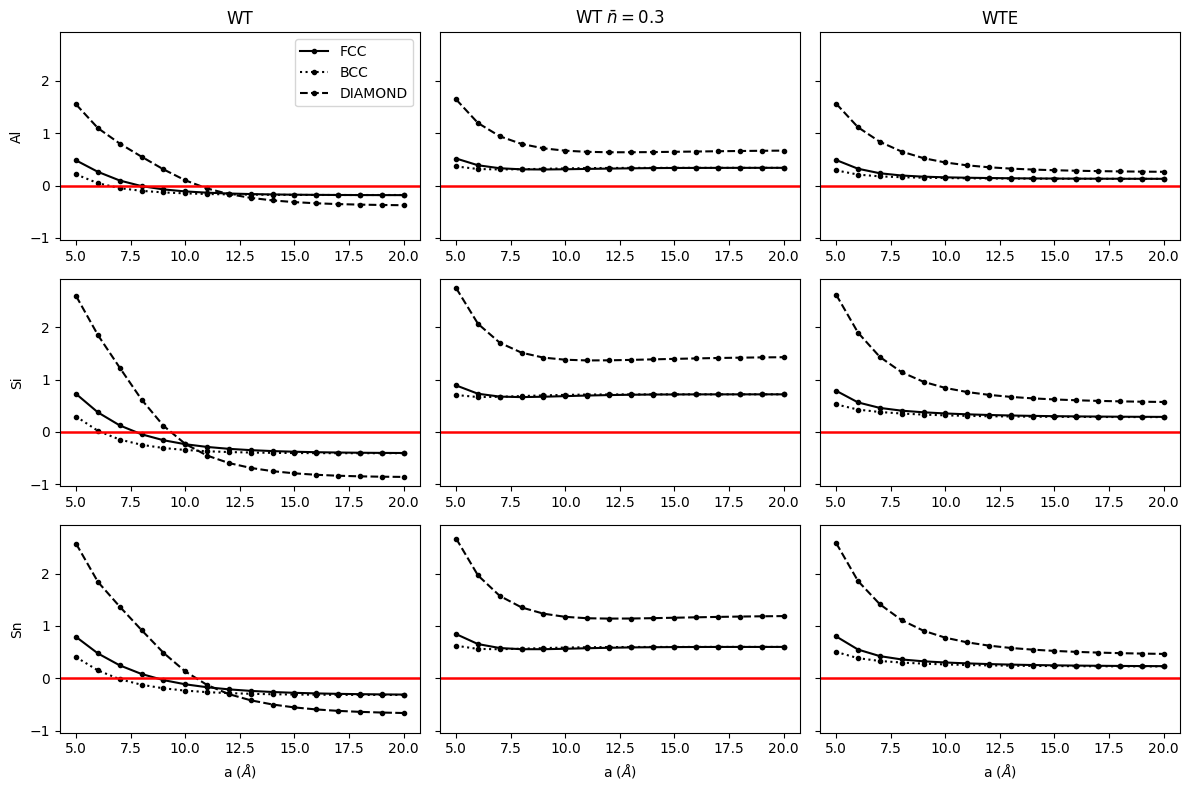

In [20]:
import matplotlib.pyplot as plt

atoms = ["Al", "Si", "Sn"]
phases = ["fcc", "bcc", "diamond"]
kedf_labels = ["WT", r"WT $\bar n = 0.3$", "WTE"]

fig, axes = plt.subplots(len(atoms), len(kedf_labels), figsize=(12, 8), sharey=True)

for i, atom in enumerate(atoms):
    for j, kedf_label in enumerate(kedf_labels):
        ax = axes[i, j]
        for phase in phases:
            mask = (
                (results_df["Atom"] == atom)
                & (results_df["Phase"] == phase)
                & (results_df["KEDF"] == kedf_label)
            )
            data = results_df.loc[mask].sort_values("a")
            if phase == 'fcc': 
                color = 'k'
                ls = '-'
            if phase == 'bcc': 
                color = 'k'
                ls = ':'
            if phase == 'diamond': 
                color = 'k'
                ls = '--'
 
            ax.plot(
                data["a"],
                data["pauli_energy"],
                marker="o",
                label=phase.upper(),
                color=color,
                ls=ls,
                markersize=3,
            )
        ax.axhline(0.0, color="red", linewidth=1.8)
        if i == 0:
            ax.set_title(kedf_label)
        if j == 0:
            ax.set_ylabel(atom)
        if i == len(atoms) - 1:
            ax.set_xlabel(r"a ($\AA$)")

axes[0, 0].legend()
plt.tight_layout()
plt.savefig("Tp_positivity_WT.pdf")
